# S05: Global Theorems about Continuous and Differentiable Functions

In [1]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt


## Roots of a cubic polynomial


 We use sympy to define
 $$f(x) = x^3 - 7 x + 1$$

In [2]:
x = sy.Symbol('x', real=True)


In [3]:

f = x**3 - 7 * x + 1

print("f(x) =")
display(f)

f(x) =


x**3 - 7*x + 1

And we plot the function:

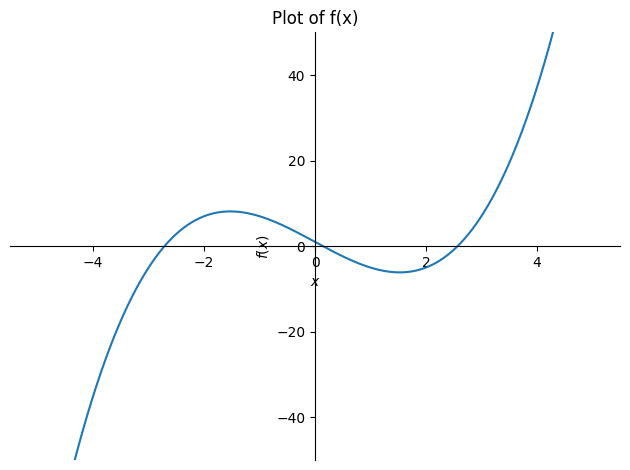

In [4]:
sy.plot(f, (x, -5, 5), ylim=(-50, 50), title='Plot of f(x)');

# Symbolic solutions for this cubic polynomial

The sympy `solve`function can be used to ask for the solutions of the cubic polynomial (in symbolic/exact format).

In [5]:
f_roots = sy.solve(f, x)
# Simplify the solutions
f_roots_simplified = [sy.simplify(root) for root in f_roots]
f_roots_simplified

[3**(2/3)*(14*2**(1/3)/3 + (1 + sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3)/36)/((1 + sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)),
 3**(2/3)*(14*2**(1/3)/3 + (1 - sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3)/36)/((1 - sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)),
 (-14*18**(1/3) - 12**(1/3)*(9 + sqrt(4035)*I)**(2/3))/(6*(9 + sqrt(4035)*I)**(1/3))]

The displayed solutions include the symbol `I` for the complex (imaginary) unit that we usually denote $i$ (recall that $i^2 = -1$). This seems to indicate that the roots of the polynomial are complex numbers, though the graphic above says otherwise.

Let us first learn how to get pretty versions of these roots using the math typesetting language called $\LaTeX$ (latex).

In [6]:
from IPython.display import Math, display

# Convert the simplified roots to LaTeX format
latex_output = [sy.latex(root) for root in f_roots_simplified]

print("Rendered LaTeX representation of simplified roots:")
for root_latex in latex_output:
    display(Math(root_latex))

Rendered LaTeX representation of simplified roots:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

They look like complex in this symbolic version. Let us ask for numerical approximations of the roots:

In [7]:
f_roots_numerical = [root.evalf() for root in f_roots_simplified]
print("Numerical values of the simplified roots (rounded to 7 digits):")
for root_num in f_roots_numerical:
    print(f"The root is {root_num}, which rounded to seven digits is: {root_num:.7f}")

Numerical values of the simplified roots (rounded to 7 digits):
The root is 0.143277321839643 + 8.470329472543e-22*I, which rounded to seven digits is: 0.1432773
The root is 2.57120142254812 - 5.42101086242752e-20*I, which rounded to seven digits is: 2.5712014
The root is -2.71447874438776, which rounded to seven digits is: -2.7144787


Thus you can see that the roots are actually real, the complex unit is just and artifact of the symbolic solution process.

In [8]:
print("Symbolic Real and Imaginary parts of the simplified roots:")
for i, root in enumerate(f_roots_simplified):
    symbolic_real_part = sy.re(root)
    symbolic_imag_part = sy.im(root)
    print(f"Root {i+1}: Real = {symbolic_real_part}, Imaginary = {symbolic_imag_part}")

Symbolic Real and Imaginary parts of the simplified roots:
Root 1: Real = 3**(2/3)*(re((1 + sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36 + 14*2**(1/3)/3)*re(1/((1 + sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3))) - 3**(2/3)*im(1/((1 + sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)))*im((1 + sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36, Imaginary = 3**(2/3)*(re((1 + sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36 + 14*2**(1/3)/3)*im(1/((1 + sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3))) + 3**(2/3)*re(1/((1 + sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)))*im((1 + sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36
Root 2: Real = -3**(2/3)*im(1/((1 - sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)))*im((1 - sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36 + 3**(2/3)*(re((1 - sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36 + 14*2**(1/3)/3)*re(1/((1 - sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3))), Imaginary = 3**(2/3)*re(1/((1 - sqrt(3)*I)*(9 + sqrt(4035)*I)**(1/3)))*im((1 - sqrt(3)*I)**2*(54 + 6*sqrt(4035)*I)**(2/3))/36 + 3**(2/3)*(re((1 - sqrt(3

# Numerical solutions with numpy, scipy and Newton's method

Now we will use numpy and the Newton method we have talked about to get numerical apprximations of the three roots.

In [9]:
# Define the derivative of f(x)
df_sym = sy.diff(f, x)

# Convert f(x) and its derivative to numpy-callable functions
f_numpy = sy.lambdify(x, f, 'numpy')
df_numpy = sy.lambdify(x, df_sym, 'numpy')

print("Original function f(x):")
display(f)
print("Derivative f'(x):")
display(df_sym)

Original function f(x):


x**3 - 7*x + 1

Derivative f'(x):


3*x**2 - 7

We can implement Newton's method with a function such as:

In [10]:
def newtons_method(func, dfunc, x0, tol=1e-7, max_iter=100):
    """Finds a root of func using Newton's method."""
    x = x0
    for i in range(max_iter):
        fx = func(x)
        dfx = dfunc(x)
        if abs(dfx) < 1e-10: # Avoid division by zero if derivative is too small
            print(f"Warning: Derivative is near zero at x = {x}. Stopping.")
            return None

        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    print(f"Warning: Did not converge within {max_iter} iterations for x0 = {x0}.")
    return x


Then we use initial guesses based for example on the graph above

In [11]:
initial_guesses = [0.1, 2.5, -2.5]

print("Roots found using Newton's Method:")
newton_roots = []
for guess in initial_guesses:
    root = newtons_method(f_numpy, df_numpy, guess)
    if root is not None:
        newton_roots.append(root)
        print(f"  Initial guess: {guess:.7f}, Found root: {root:.7f}")

Roots found using Newton's Method:
  Initial guess: 0.1000000, Found root: 0.1432773
  Initial guess: 2.5000000, Found root: 2.5712014
  Initial guess: -2.5000000, Found root: -2.7144787


## SciPy version of Newton's method

SciPy is, according to the [Wikipedia](https://en.wikipedia.org/wiki/SciPy), a free and open-source Python library used for scientific computing and technical computing.  Let us now use [SciPy](https://docs.scipy.org/doc/scipy/tutorial/index.html) to apply its [Newton's method direct implementation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html) to the same problem.

In [17]:
from scipy.optimize import newton

print("Roots found using scipy.optimize.newton:")
scipy_roots = []
for guess in initial_guesses:
    try:
        root = newton(f_numpy, guess, fprime=df_numpy)
        scipy_roots.append(root)
        print(f"  Initial guess: {guess:.7f}, Found root: {root:.7f}")
    except RuntimeError as e:
        print(f"  Initial guess: {guess:.3f}, Error: {e}")

Roots found using scipy.optimize.newton:
  Initial guess: 0.1000000, Found root: 0.1432773
  Initial guess: 2.5000000, Found root: 2.5712014
  Initial guess: -2.5000000, Found root: -2.7144787


## Optional

What do you know about exact solutions for polynomial equations? You have certainly learnt symbolic formulas for quadratic equations. When were they discovered? Are there similar formulas for all polynomial equations? What about non polynomial equations? What is a transcendent number? Do you know some examples?